# Customer Churn Prediction using Machine Learning

Predict whether a telecom customer will churn using supervised classification.

**Pipeline**
1. Load & clean data  
2. Exploratory Data Analysis  
3. Feature engineering (80/20 split + scaling)  
4. Train models + 5-Fold CV  
5. Evaluate, pick best model, save  

> Run all cells **top → bottom** (or click **Run All**).


## 0. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 110})

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "dataset").exists() else NOTEBOOK_DIR.parent
DATA_PATH = ROOT / "dataset" / "Telco-Customer-Churn.csv"
IMAGES = ROOT / "images"
MODEL_DIR = ROOT / "model"
IMAGES.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(ROOT / "src"))

print("=" * 60)
print("  CUSTOMER CHURN PREDICTION — NOTEBOOK")
print("=" * 60)
print(f"  Project root : {ROOT}")
print(f"  Dataset      : {DATA_PATH.exists()}")
print("=" * 60)


  CUSTOMER CHURN PREDICTION — NOTEBOOK
  Project root : C:\Users\Teja Srinivasulu\OneDrive\Desktop\Internspark - task1\Customer-Churn-Prediction
  Dataset      : True


## 1. Load & Clean Data

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()


Raw shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Dtypes:\n", df_raw.dtypes)
print("\nMissing values:\n", df_raw.isnull().sum())
df_raw.describe(include="all").T


Dtypes:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df = df_raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"Missing TotalCharges: {df['TotalCharges'].isna().sum()}")

df = df.dropna().drop_duplicates()
df = df.drop(columns=["customerID"])
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1}).astype(int)
df["SeniorCitizen"] = df["SeniorCitizen"].astype(int)

print(f"Cleaned shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Churn rate    : {df['Churn'].mean():.2%}")
df.head()


Missing TotalCharges: 11


Cleaned shape : 7,032 rows × 20 columns
Churn rate    : 26.58%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 2. Exploratory Data Analysis

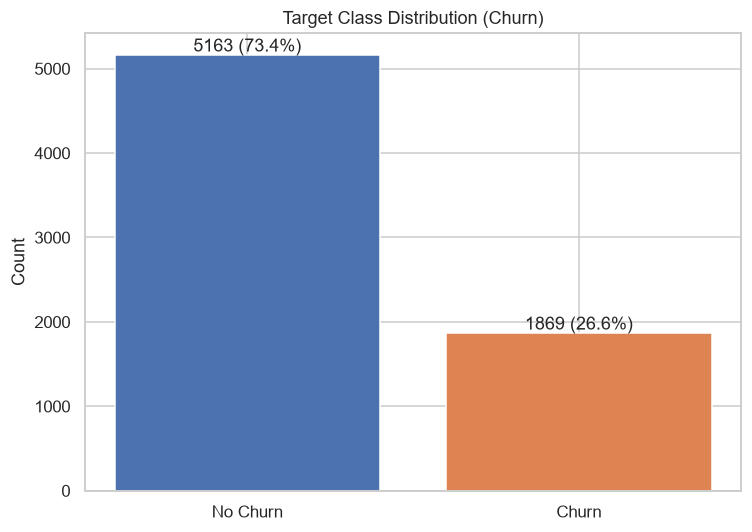

In [5]:
# Target distribution
fig, ax = plt.subplots(figsize=(7, 5))
counts = df["Churn"].value_counts().sort_index()
colors = ["#4C72B0", "#DD8452"]
ax.bar(["No Churn", "Churn"], counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + 40, f"{v} ({v/len(df):.1%})", ha="center")
ax.set_title("Target Class Distribution (Churn)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(IMAGES / "target_distribution.png")
plt.show()


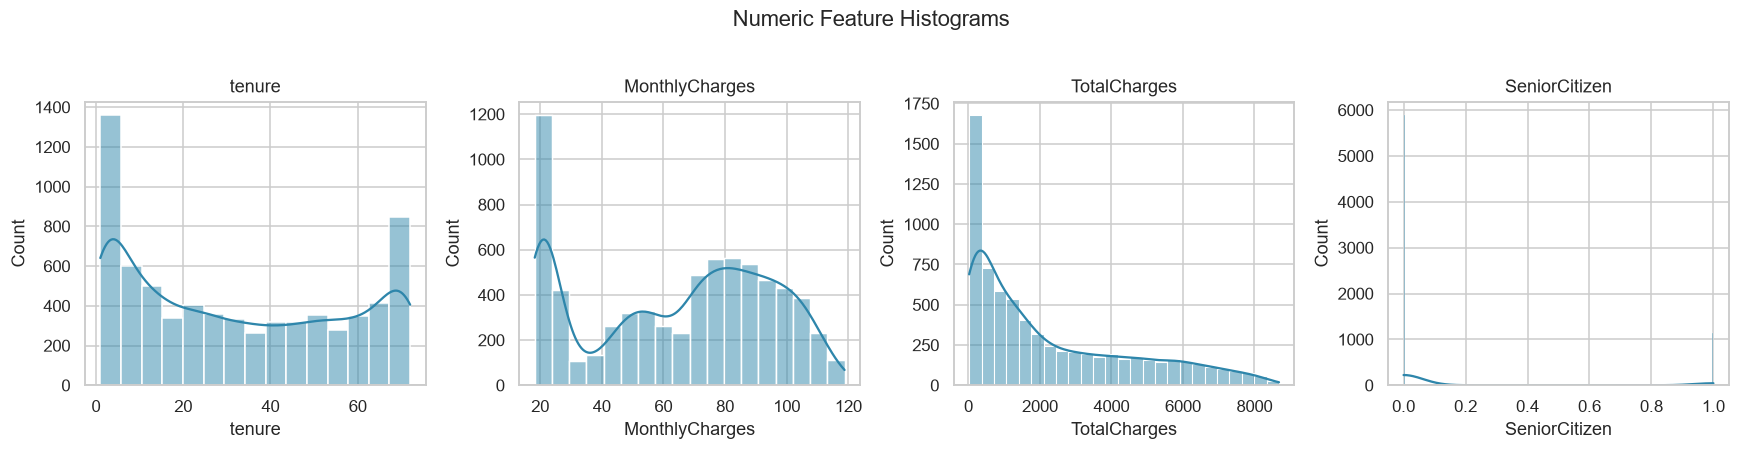

In [6]:
# Histograms
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#2E86AB")
    ax.set_title(col)
fig.suptitle("Numeric Feature Histograms", y=1.02)
plt.tight_layout()
plt.savefig(IMAGES / "histogram.png")
plt.show()


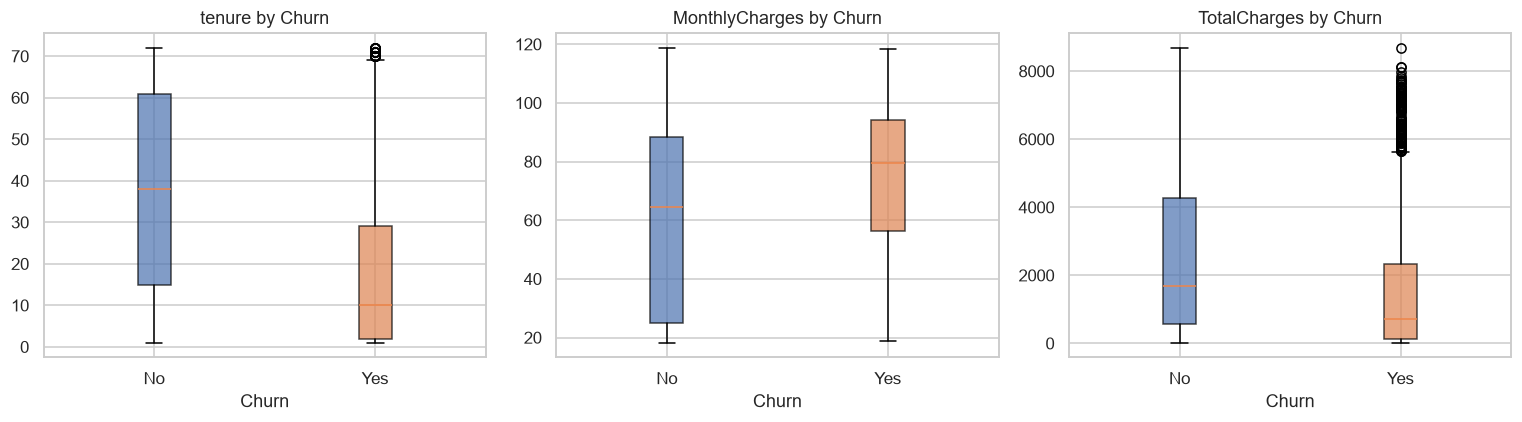

In [7]:
# Boxplots by churn
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    bp = ax.boxplot(
        [df.loc[df.Churn == 0, col], df.loc[df.Churn == 1, col]],
        tick_labels=["No", "Yes"], patch_artist=True,
    )
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_title(f"{col} by Churn")
    ax.set_xlabel("Churn")
plt.tight_layout()
plt.savefig(IMAGES / "boxplot.png")
plt.show()


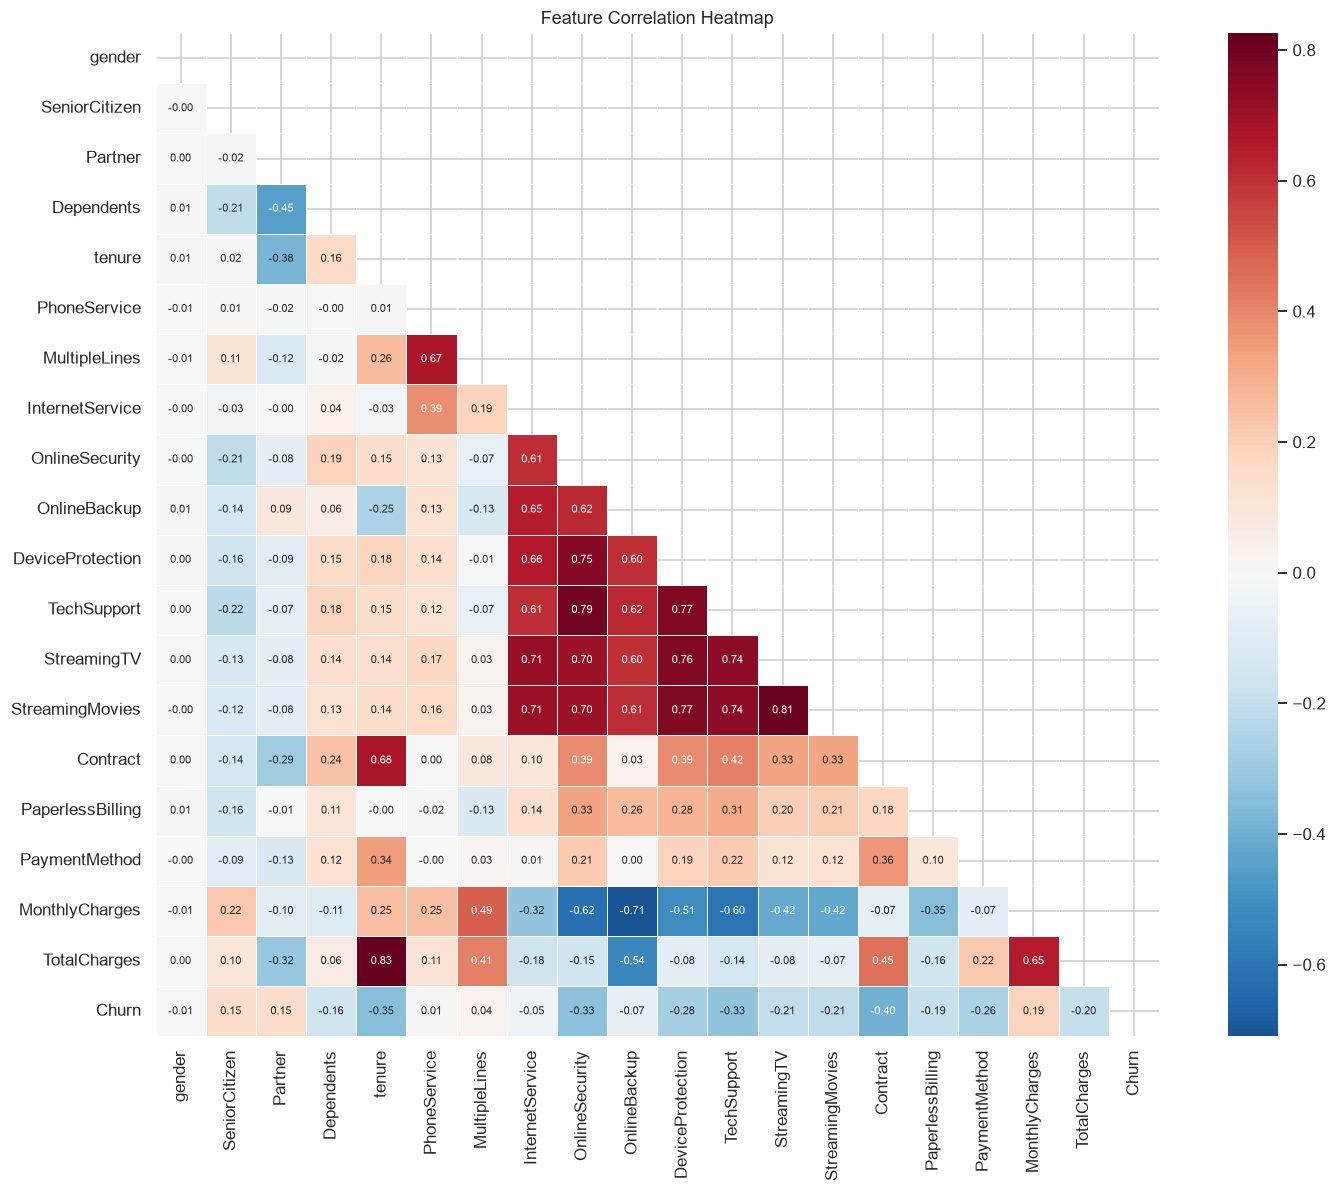

In [8]:
# Correlation heatmap
df_corr = df.copy()
for col in df_corr.select_dtypes(include=["object", "string"]).columns:
    df_corr[col] = pd.factorize(df_corr[col])[0]

plt.figure(figsize=(14, 11))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.4, annot_kws={"size": 7})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(IMAGES / "heatmap.png")
plt.show()


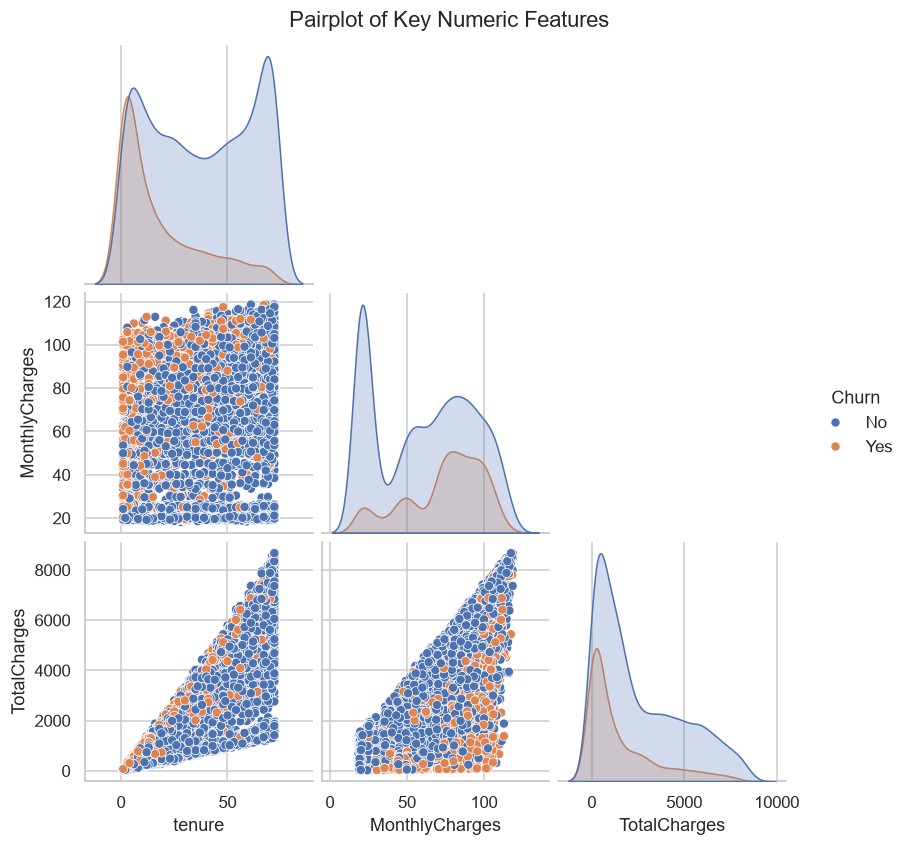

In [9]:
# Pairplot
pair_df = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].copy()
pair_df["Churn"] = pair_df["Churn"].map({0: "No", 1: "Yes"})
g = sns.pairplot(pair_df, hue="Churn",
                 palette={"No": "#4C72B0", "Yes": "#DD8452"},
                 diag_kind="kde", corner=True)
g.fig.suptitle("Pairplot of Key Numeric Features", y=1.02)
g.savefig(IMAGES / "pairplot.png")
plt.show()


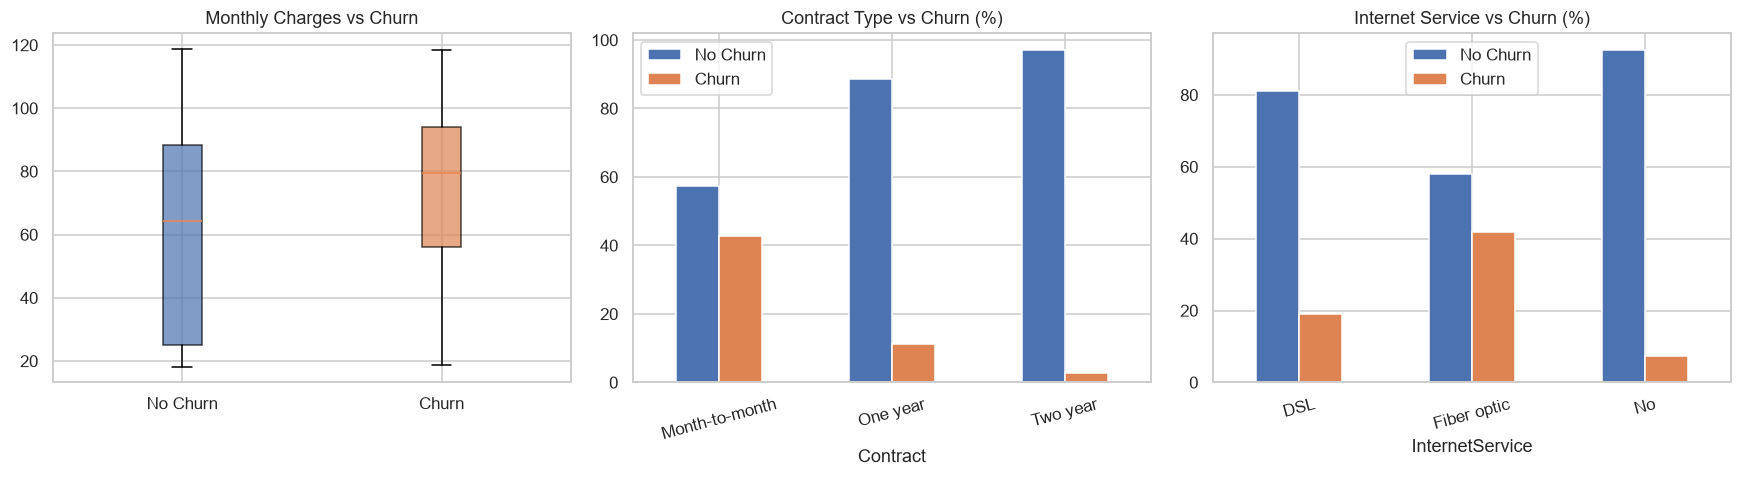

In [10]:
# Monthly Charges / Contract / Internet Service vs Churn
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

bp = axes[0].boxplot(
    [df.loc[df.Churn == 0, "MonthlyCharges"], df.loc[df.Churn == 1, "MonthlyCharges"]],
    tick_labels=["No Churn", "Churn"], patch_artist=True,
)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[0].set_title("Monthly Charges vs Churn")

ct = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
ct.columns = ["No Churn", "Churn"]
ct.plot(kind="bar", ax=axes[1], color=colors)
axes[1].set_title("Contract Type vs Churn (%)")
axes[1].tick_params(axis="x", rotation=15)

it = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
it.columns = ["No Churn", "Churn"]
it.plot(kind="bar", ax=axes[2], color=colors)
axes[2].set_title("Internet Service vs Churn (%)")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(IMAGES / "monthly_charges_vs_churn.png")
plt.savefig(IMAGES / "contract_vs_churn.png")
plt.savefig(IMAGES / "internet_service_vs_churn.png")
plt.show()


## 3. Feature Engineering

In [11]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
print("Numeric     :", numeric_features)
print("Categorical :", categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
         categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_s = preprocessor.fit_transform(X_train)
X_test_s = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out().tolist()
y_train = np.asarray(y_train, dtype=int)
y_test = np.asarray(y_test, dtype=int)

print(f"Train: {X_train_s.shape} | Test: {X_test_s.shape} | Features: {len(feature_names)}")


Numeric     : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Train: (5625, 30) | Test: (1407, 30) | Features: 30


## 4. Models + 5-Fold Cross Validation

In [12]:
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=2,
        random_state=42, class_weight="balanced", n_jobs=-1,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=5, random_state=42, class_weight="balanced",
    ),
    "SVM": CalibratedClassifierCV(
        SVC(kernel="rbf", random_state=42, class_weight="balanced"), ensemble=False
    ),
    "KNN": KNeighborsClassifier(n_neighbors=7),
}
if HAS_XGB:
    models["XGBoost"] = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.08,
        subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
        random_state=42, n_jobs=-1,
    )

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
print("5-Fold Cross Validation")
print("-" * 60)
for name, model in models.items():
    acc = cross_val_score(model, X_train_s, y_train, cv=skf, scoring="accuracy", n_jobs=1)
    auc = cross_val_score(model, X_train_s, y_train, cv=skf, scoring="roc_auc", n_jobs=1)
    cv_rows.append({
        "Model": name,
        "CV Accuracy (mean)": acc.mean(),
        "CV Accuracy (std)": acc.std(),
        "CV ROC-AUC (mean)": auc.mean(),
        "CV ROC-AUC (std)": auc.std(),
    })
    print(f"  ✔ {name:22s}  Acc={acc.mean():.4f}±{acc.std():.4f}  AUC={auc.mean():.4f}±{auc.std():.4f}")

pd.DataFrame(cv_rows)


5-Fold Cross Validation
------------------------------------------------------------


  ✔ Logistic Regression     Acc=0.7516±0.0050  AUC=0.8459±0.0054


  ✔ Random Forest           Acc=0.7687±0.0060  AUC=0.8450±0.0055


  ✔ Decision Tree           Acc=0.7156±0.0097  AUC=0.8005±0.0155


  ✔ SVM                     Acc=0.7941±0.0074  AUC=0.8278±0.0064


  ✔ KNN                     Acc=0.7735±0.0060  AUC=0.8011±0.0089


  ✔ XGBoost                 Acc=0.7964±0.0063  AUC=0.8412±0.0047


,Model,CV Accuracy (mean),CV Accuracy (std),CV ROC-AUC (mean),CV ROC-AUC (std)
0,Logistic Regression,0.751644,0.005016,0.845928,0.005414
1,Random Forest,0.768711,0.005960,0.845014,0.005537
2,Decision Tree,0.715556,0.009688,0.800475,0.015469
3,SVM,0.794133,0.007407,0.827796,0.006376
4,KNN,0.773511,0.005960,0.801073,0.008868
5,XGBoost,0.796444,0.006285,0.841195,0.004722


## 5. Train, Evaluate & Compare

In [13]:
def evaluate(model, name):
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }
    print("=" * 60)
    print(f"  {name}")
    print("=" * 60)
    for k, v in metrics.items():
        if k != "Model":
            print(f"    {k:<12}: {v:.4f}")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
    return metrics, y_pred, y_proba, model

results, preds, probs, fitted = [], {}, {}, {}
for name, model in models.items():
    m, yp, yp_proba, fitted_model = evaluate(model, name)
    results.append(m)
    preds[name] = yp
    probs[name] = yp_proba
    fitted[name] = fitted_model

metrics_df = pd.DataFrame(results).set_index("Model")
print("\n=== MODEL COMPARISON ===")
metrics_df.round(4)



  Logistic Regression
    Accuracy    : 0.7264
    Precision   : 0.4909
    Recall      : 0.7941
    F1 Score    : 0.6067
    ROC-AUC     : 0.8353
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



  Random Forest
    Accuracy    : 0.7541
    Precision   : 0.5261
    Recall      : 0.7540
    F1 Score    : 0.6198
    ROC-AUC     : 0.8324
              precision    recall  f1-score   support

    No Churn       0.89      0.75      0.82      1033
       Churn       0.53      0.75      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.80      0.75      0.77      1407

  Decision Tree
    Accuracy    : 0.7193
    Precision   : 0.4830
    Recall      : 0.7995
    F1 Score    : 0.6022
    ROC-AUC     : 0.8104
              precision    recall  f1-score   support

    No Churn       0.90      0.69      0.78      1033
       Churn       0.48      0.80      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407



  SVM
    Accuracy    : 0.7903
    Precision   : 0.5980
    Recall      : 0.6444
    F1 Score    : 0.6203
    ROC-AUC     : 0.8133
              precision    recall  f1-score   support

    No Churn       0.87      0.84      0.86      1033
       Churn       0.60      0.64      0.62       374

    accuracy                           0.79      1407
   macro avg       0.73      0.74      0.74      1407
weighted avg       0.80      0.79      0.79      1407

  KNN
    Accuracy    : 0.7697
    Precision   : 0.5668
    Recall      : 0.5668
    F1 Score    : 0.5668
    ROC-AUC     : 0.7953
              precision    recall  f1-score   support

    No Churn       0.84      0.84      0.84      1033
       Churn       0.57      0.57      0.57       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407



  XGBoost
    Accuracy    : 0.7811
    Precision   : 0.6000
    Recall      : 0.5294
    F1 Score    : 0.5625
    ROC-AUC     : 0.8261
              precision    recall  f1-score   support

    No Churn       0.84      0.87      0.85      1033
       Churn       0.60      0.53      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407


=== MODEL COMPARISON ===


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7264,0.4909,0.7941,0.6067,0.8353
Random Forest,0.7541,0.5261,0.7540,0.6198,0.8324
Decision Tree,0.7193,0.4830,0.7995,0.6022,0.8104
SVM,0.7903,0.5980,0.6444,0.6203,0.8133
KNN,0.7697,0.5668,0.5668,0.5668,0.7953
XGBoost,0.7811,0.6000,0.5294,0.5625,0.8261


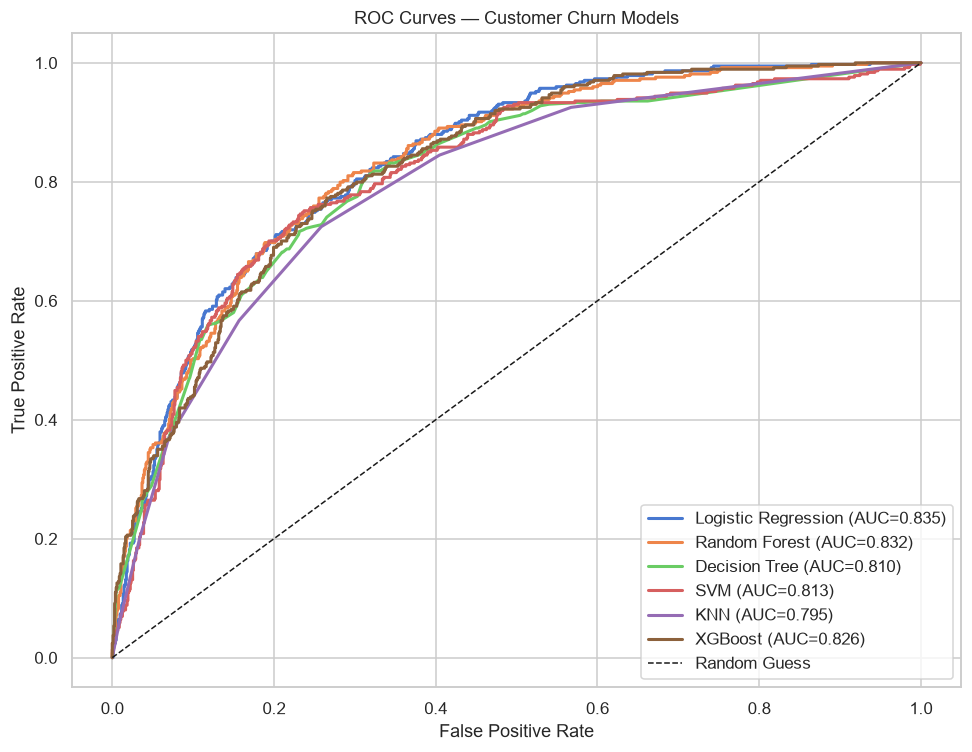

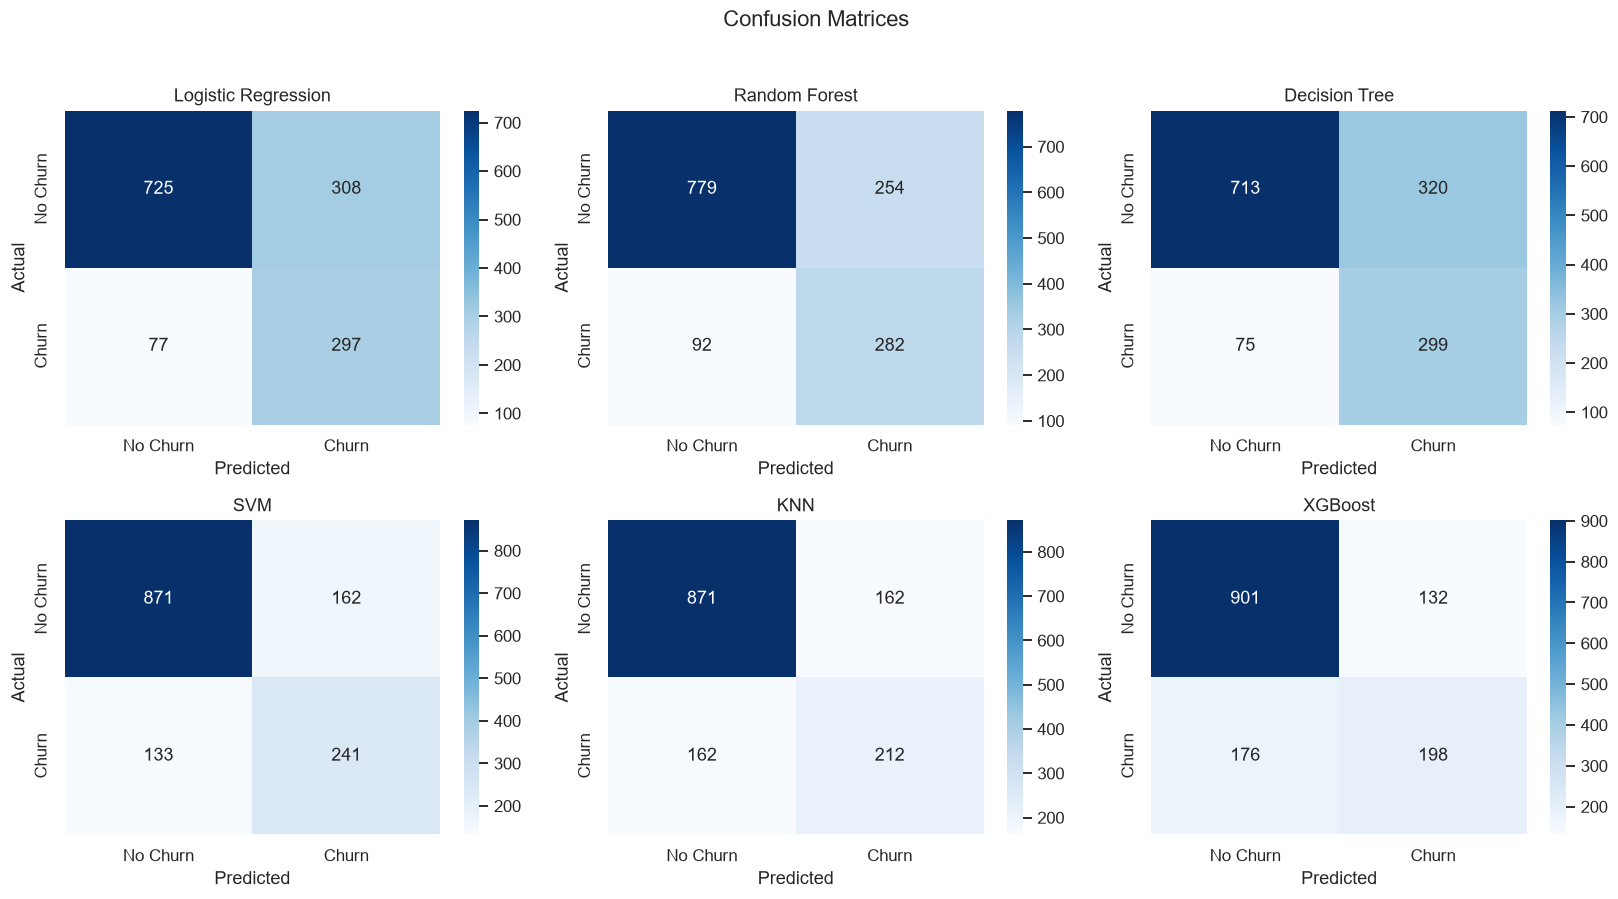

In [14]:
# ROC curves
plt.figure(figsize=(9, 7))
for name, proba in probs.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Customer Churn Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(IMAGES / "roc_curve.png")
plt.show()

# Confusion matrices
n = len(preds)
cols = min(3, n)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)
for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
    ax.set_title(name)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle("Confusion Matrices", y=1.02)
plt.tight_layout()
plt.savefig(IMAGES / "confusion_matrix.png")
plt.show()


## 6. Feature Importance (Random Forest)

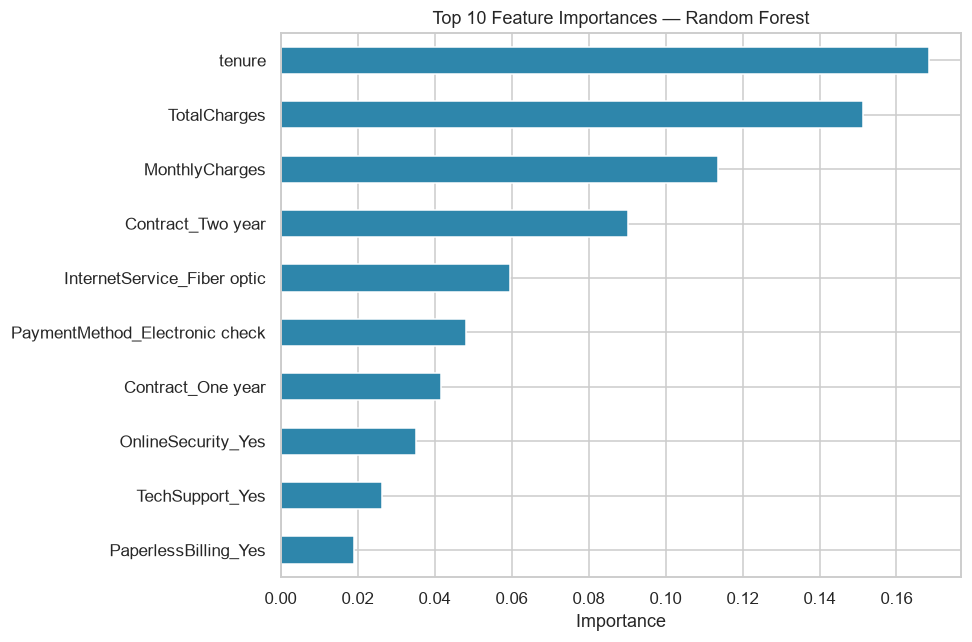

Top 10 important features:
   1. tenure                               0.1684
   2. TotalCharges                         0.1514
   3. MonthlyCharges                       0.1136
   4. Contract_Two year                    0.0903
   5. InternetService_Fiber optic          0.0595
   6. PaymentMethod_Electronic check       0.0482
   7. Contract_One year                    0.0417
   8. OnlineSecurity_Yes                   0.0351
   9. TechSupport_Yes                      0.0263
  10. PaperlessBilling_Yes                 0.0191


In [15]:
rf = fitted["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=feature_names)
importances.index = importances.index.str.replace(r"^(num|cat)__", "", regex=True)
top10 = importances.nlargest(10).sort_values()

plt.figure(figsize=(9, 6))
top10.plot(kind="barh", color="#2E86AB")
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances — Random Forest")
plt.tight_layout()
plt.savefig(IMAGES / "feature_importance.png")
plt.show()

print("Top 10 important features:")
for i, (feat, imp) in enumerate(importances.nlargest(10).items(), 1):
    print(f"  {i:2d}. {feat:35s}  {imp:.4f}")


## 7. Select & Save Best Model

In [16]:
ranked = metrics_df.sort_values(by=["ROC-AUC", "Accuracy"], ascending=False)
best_name = ranked.index[0]
best_model = fitted[best_name]

print("=" * 60)
print(f"  BEST MODEL → {best_name}")
print("=" * 60)
print(ranked.loc[best_name].round(4))

joblib.dump({"model": best_model, "model_name": best_name}, MODEL_DIR / "best_model.pkl")
joblib.dump(preprocessor, MODEL_DIR / "preprocessor.pkl")
metrics_df.to_csv(MODEL_DIR / "metrics.csv")
print(f"\n✔ Saved best model → {MODEL_DIR / 'best_model.pkl'}")
ranked.round(4)


  BEST MODEL → Logistic Regression
Accuracy     0.7264
Precision    0.4909
Recall       0.7941
F1 Score     0.6067
ROC-AUC      0.8353
Name: Logistic Regression, dtype: float64

✔ Saved best model → C:\Users\Teja Srinivasulu\OneDrive\Desktop\Internspark - task1\Customer-Churn-Prediction\model\best_model.pkl


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7264,0.4909,0.7941,0.6067,0.8353
Random Forest,0.7541,0.5261,0.7540,0.6198,0.8324
XGBoost,0.7811,0.6000,0.5294,0.5625,0.8261
SVM,0.7903,0.5980,0.6444,0.6203,0.8133
Decision Tree,0.7193,0.4830,0.7995,0.6022,0.8104
KNN,0.7697,0.5668,0.5668,0.5668,0.7953


## 8. Quick Prediction Demo

In [17]:
loaded = joblib.load(MODEL_DIR / "best_model.pkl")
prep = joblib.load(MODEL_DIR / "preprocessor.pkl")
model = loaded["model"]

sample = X_test.head(5)
X_s = prep.transform(sample)
proba = model.predict_proba(X_s)[:, 1]
out = sample.copy()
out["churn_probability"] = np.round(proba, 4)
out["churn_prediction"] = (proba >= 0.5).astype(int)
out[["churn_probability", "churn_prediction"]]


,churn_probability,churn_prediction
974,0.0516,0
619,0.7836,1
4289,0.0144,0
3721,0.4006,0
4533,0.2329,0


## Summary

| Item | Result |
|------|--------|
| Dataset | Telco Customer Churn |
| Best criterion | Highest ROC-AUC |
| Artifacts | `model/best_model.pkl`, `images/` |

**Done.** Re-run anytime with **Run All**.
